# 📊 Analyse des performances et du comportement client – E-commerce Sephora💄🛍️

## 💡 Analyse exploratoire et préparation des données

##### L'ensemble de données initial comprend plusieurs tables, dont une table d'informations produit (product_info) et cinq tables d'avis clients (reviews), divisées en plusieurs parties en raison du volume important de données.

##### Pour ce projet, il a été décidé de travailler avec un échantillon représentatif, en sélectionnant la table reviews_0-250 afin d'optimiser les performances de traitement et la lisibilité des analyses.

##### L'analyse repose donc sur deux tables principales : les informations produit et les avis clients, permettant ainsi de comparer les caractéristiques du produit aux retours des utilisateurs.

### 1. Importation des bibliothèques et des données

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Chargement des fichiers
product_info = pd.read_csv(R"C:\Users\diana\OneDrive - Data Suits\FORMATION DATA ANALYST - Octobre 2025\FORMATION DATA ANALYST - Octobre 2025\PROJET FINAL\archive\product_info.csv",low_memory=False)
reviews = pd.read_csv(R"C:\Users\diana\OneDrive - Data Suits\FORMATION DATA ANALYST - Octobre 2025\FORMATION DATA ANALYST - Octobre 2025\PROJET FINAL\archive\reviews_0-250.csv",low_memory=False)

### 2. Analyse du volume des données

In [4]:
print("Product info:", product_info.shape)
print("Reviews:", reviews.shape)

Product info: (8494, 27)
Reviews: (602130, 19)


### 3. Aperçu des données

In [5]:
product_info.head(1)

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN


In [6]:
product_info.head(1)

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN


### 4. Vérification de la qualité des données

In [7]:
print("Valeurs manquantes - Product info")
print(product_info.isnull().sum())

print("\nValeurs manquantes - Reviews")
print(reviews.isnull().sum())

Valeurs manquantes - Product info
product_id               0
product_name             0
brand_id                 0
brand_name               0
loves_count              0
rating                 278
reviews                278
size                  1631
variation_type        1444
variation_value       1598
variation_desc        7244
ingredients            945
price_usd                0
value_price_usd       8043
sale_price_usd        8224
limited_edition          0
new                      0
online_only              0
out_of_stock             0
sephora_exclusive        0
highlights            2207
primary_category         0
secondary_category       8
tertiary_category      990
child_count              0
child_max_price       5740
child_min_price       5740
dtype: int64

Valeurs manquantes - Reviews
Unnamed: 0                       0
author_id                        0
rating                           0
is_recommended              117486
helpfulness                 331832
total_feedback_coun

### 5. Analyse statistique descriptive

In [8]:
reviews.describe()

,Unnamed: 0,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,price_usd
count,602130.00000,602130.000000,484644.000000,270298.000000,602130.000000,602130.000000,602130.000000,602130.000000
mean,301064.50000,4.311838,0.837922,0.769722,3.660661,0.765473,2.895189,45.723937
std,173820.10313,1.143692,0.368522,0.319103,25.848330,4.968115,22.628880,35.743990
min,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,150532.25000,4.000000,1.000000,0.666667,0.000000,0.000000,0.000000,23.500000
50%,301064.50000,5.000000,1.000000,0.944444,0.000000,0.000000,0.000000,38.000000
75%,451596.75000,5.000000,1.000000,1.000000,3.000000,0.000000,2.000000,60.000000
max,602129.00000,5.000000,1.000000,1.000000,5464.000000,573.000000,5050.000000,380.000000


In [9]:
product_info.describe()

,brand_id,loves_count,rating,reviews,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,child_count,child_max_price,child_min_price
count,8494.000000,8.494000e+03,8216.000000,8216.000000,8494.000000,451.000000,270.000000,8494.000000,8494.000000,8494.000000,8494.000000,8494.000000,8494.000000,2754.000000,2754.000000
mean,5422.440546,2.917957e+04,4.194513,448.545521,51.655595,91.168537,20.207889,0.070285,0.071698,0.219096,0.073699,0.279374,1.631622,53.792023,39.665802
std,1709.595957,6.609212e+04,0.516694,1101.982529,53.669234,79.195631,24.327352,0.255642,0.258002,0.413658,0.261296,0.448718,5.379470,58.765894,38.685720
min,1063.000000,0.000000e+00,1.000000,1.000000,3.000000,0.000000,1.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000
25%,5333.000000,3.758000e+03,3.981725,26.000000,25.000000,45.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,19.000000
50%,6157.500000,9.880000e+03,4.289350,122.000000,35.000000,67.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000,28.000000
75%,6328.000000,2.684125e+04,4.530525,418.000000,58.000000,108.500000,25.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,59.000000,42.000000
max,8020.000000,1.401068e+06,5.000000,21281.000000,1900.000000,617.000000,320.000000,1.000000,1.000000,1.000000,1.000000,1.000000,105.000000,570.000000,400.000000


### 6. Nombre de produits uniques

In [10]:
print("Nombre de produits uniques dans les reviews :")
print(reviews["product_id"].nunique())

Nombre de produits uniques dans les reviews :
250


### 7. Fusion des données (création du dataset final)

In [11]:
final_dataset = reviews.merge(product_info, on="product_id", how="left")

print("Taille du dataset final :", final_dataset.shape)

Taille du dataset final : (602130, 45)


#### ⬆️💡 Observation

La fusion des données a été réalisée via une jointure de type Left Join sur la clé product_id, permettant d’enrichir chaque avis avec les informations produit correspondantes. 
Cette étape est essentielle pour centraliser les données et constituer un dataset complet, prêt pour les étapes de transformation et d’analyse.

#### 7.1 Validation du dataset final (Power BI)

In [12]:
# Chargement du dataset final exporté depuis Power BI
final_powerbi = pd.read_excel(R"C:\Users\diana\OneDrive - Data Suits\FORMATION DATA ANALYST - Octobre 2025\FORMATION DATA ANALYST - Octobre 2025\PROJET FINAL\final_dataset.xlsx")

print("Taille du dataset Power BI :", final_powerbi.shape)

Taille du dataset Power BI : (598651, 11)


In [13]:
final_powerbi.head(2)

,Rating_qualification client,Date_ review,Review_text,Product_id,Marque_name,price_usd,Edition_limitée,Edition_ Nouveauté,Edition_exclusive,Product_name,likes_count
0,5,lundi 20 mars 2023,I kid you not I’ve been buying this for 2 year...,P394639,Belif,38.0,False,False,False,The True Cream Aqua,265050
1,5,mardi 14 mars 2023,This is a staple in my routine! Absolutely lov...,P394639,Belif,38.0,False,False,False,The True Cream Aqua,265050


In [14]:
print("Python final_dataset :", final_dataset.shape)
print("Power BI final_dataset :", final_powerbi.shape)

Python final_dataset : (602130, 45)
Power BI final_dataset : (598651, 11)


#### ⬆️💡 Observation

Le dataset final dans Power BI présente un volume différent en raison des étapes de nettoyage et de transformation supplémentaires, notamment le filtrage des données, la suppression des valeurs incohérentes et la sélection d’un échantillon 
pertinent pour l’analyse.
Cette étape permet de valider la cohérence entre les données préparées en Python et celles exploitées dans Power BI, tout en justifiant les écarts liés aux transformations appliquées.

### 8. Agrégation des données au niveau produit (table Product_Summary)

In [23]:
# Agrégation des données au niveau produit à partir du dataset final Power BI

product_summary = final_powerbi.groupby("Product_id").agg({
    
    # Une seule valeur par produit (car répétée dans chaque review)
    "Product_name": "first",
    "Marque_name": "first",
    "price_usd": "first",

    # Moyenne des notes (satisfaction client)
   "Rating_qualification client": lambda x: round(x.mean(), 1),

    # Nombre total de reviews par produit
    "Review_text": "count",

    # Nombre total de likes (valeur identique par produit)
    "likes_count": "max",

    # Variables booléennes
    "Edition_exclusive": "max",
    "Edition_limitée": "max",
    "Edition_ Nouveauté": "max"

}).reset_index()


# Renommage des colonnes
product_summary.rename(columns={
    "product_name": "Product Name",
    "Marque_name": "Marque",
    "price_usd": "Price",
    "Rating_qualification client": "Rating Moyen",
    "Review_text": "Total reviews",
    "likes_count": "Total likes",
    "Edition_exclusive": "Edition exclusive",
    "Edition_limitée": "Edition limited",
    "Edition_ Nouveauté": "Edition nouveauté"
}, inplace=True)


print("Taille de la table produit :", product_summary.shape)
product_summary.head(2)

Taille de la table produit : (250, 10)


,Product_id,Product_name,Marque,Price,Rating Moyen,Total reviews,Total likes,Edition exclusive,Edition limited,Edition nouveauté
0,P114902,Goodbye Acne Max,Peter Thomas Roth,48.0,4.4,1516,56955,False,False,False
1,P12045,Grape Water Moisturizing Face,Caudalie,12.0,4.4,1672,140024,False,False,False


#### ⬆️💡 Observation

L’agrégation des données à partir du dataset final Power BI permet de transformer des données répétitives au niveau des avis en indicateurs consolidés au niveau produit.
Cette approche garantit la cohérence des résultats entre Python et Power BI, tout en facilitant l’analyse de la performance produit à travers des indicateurs fiables et comparables

### 9. Comparaison avant / après transformation

In [31]:
# Analyse comparative des données

print("----- 📊ANALYSE DES VOLUMES -----\n")

print(f"✔️ Info produits (product_info) : {product_info.shape[0]} lignes")
print(f"✔️ Info reviews (reviews) : {reviews.shape[0]} lignes")

print("\nAprès fusion des données :")
print(f"✔️ Dataset final Python : {final_dataset.shape[0]} lignes")

print("\nAprès nettoyage et préparation dans Power BI :")
print(f"✔️ Dataset final Power BI : {final_powerbi.shape[0]} lignes")

print("\nAprès agrégation au niveau produit :")
print(f"✔️ Nombre de produits analysés : {product_summary.shape[0]} lignes")

----- 📊ANALYSE DES VOLUMES -----

✔️ Info produits (product_info) : 8494 lignes
✔️ Info reviews (reviews) : 602130 lignes

Après fusion des données :
✔️ Dataset final Python : 602130 lignes

Après nettoyage et préparation dans Power BI :
✔️ Dataset final Power BI : 598651 lignes

Après agrégation au niveau produit :
✔️ Nombre de produits analysés : 250 lignes


### 10. Visualisation : distribution des ratings

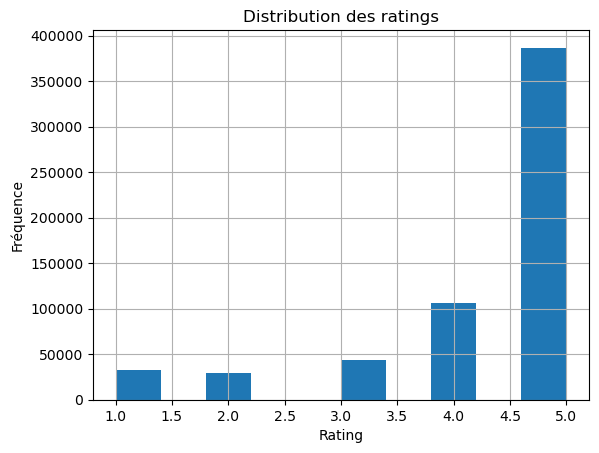

In [30]:
# Visualisation de la distribution des ratings à partir du dataset final Power BI

final_powerbi["Rating_qualification client"].hist()

plt.title("Distribution des ratings")
plt.xlabel("Rating")
plt.ylabel("Fréquence")

plt.show()

#### ⬆️💡 Observation

Cette visualisation permet d’analyser la distribution des notes attribuées par les utilisateurs, afin de mieux comprendre la perception globale des produits.

### 11. Conclusion

#### 💥Analyse terminée : les données ont été nettoyées, fusionnées et agrégées pour une exploitation optimale dans Power BI.

Cette analyse a permis de structurer et transformer des données brutes en un dataset exploitable, en passant par des étapes clés de nettoyage, de fusion et d’agrégation.

L’approche adoptée a consisté à travailler sur un échantillon représentatif afin d’optimiser la performance et la lisibilité des analyses, tout en conservant une base suffisamment riche pour garantir la pertinence des résultats.

La transformation des données, notamment le passage d’un niveau granulaire (avis) à un niveau agrégé (produit), a permis de construire des indicateurs fiables pour évaluer la performance des produits.

Enfin, cette préparation en Python a assuré la cohérence et la qualité des données avant leur exploitation dans Power BI, permettant ainsi de produire des analyses claires, pertinentes et orientées décision.